#MULTI-CAM MOVINET CLASSIFICATION

###Explications générales





Ce script permet d'avoir une approche multi-entrées pour l'entrainement de l'IA  
Il permet de choisir combien de caméras prendre en compte et ainsi ajuster le nombre d'entrées créées : ici une entrée par caméra

Résumé rapide des étapes du script :
-  Chargement et pré-traitement des vidéos (à partir des vidéos des caméras pas du TV show)

- Extraction des clips autour des tags (actifs) et des clips aléatoires à partir des vidéos passives ;

- Pré-extraction des "features" à l'aide du backbone MoViNet A5 pré-entraîné ;

- Construction d'un modèle Keras multi-caméras pour la classification binaire (passif/actif) ;

- Entrainement et évaluation du modèle (métriques et matrice de confusion)

Entrée :

- Vidéos .mp4 et tags info.txt
- Paramètres d'entrainement et configuration multi-caméras

Sortie :

- classification binaire (0 = passif, 1 = actif)

NB :

- Dans cette version le backbone est donc gelé et ainsi seule la tête de classification est entraînée

- Pour ajouter d'autres modalités (son, ECG) pour un modèle d'attention multimodal, utiliser la logique de ce script serait sûrement une bonne idée

## Installation des modules et imports

Importation des modules nécéssaires



In [5]:
import os # Gestion des fichiers et chemins

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Permet de controler les print de TensorFlow : 0 = tout, 1 = info, 2 = warning, 3 = erreur

import cv2 # OpenCV, traitement vidéos
import PIL # Affichage et traitement d'images
import absl.logging # Permet de gérer les logs (en soit les "print", messages du programme)
import re # Permet de chercher et manipuler du texte (ici pour trier "video1_2" avant "video1_10" par ex)
import random  # Permet de générer des nombres aléatoires
from datetime import datetime, timedelta # Gestion des dates et des temps, permet de convertir, comparer et manipuler les timestamps
from tqdm import tqdm # Permet d'afficher des barres de progression lors de boucles longues

import tensorflow_datasets as tfds # Permet de télécharger les jeux de données déjà prêts de TensorFlow
import tensorflow as tf # Bibliothèque (outils) principale pour créer, entraîner et exécuter des modèles d'IA

import logging
tf.get_logger().setLevel(logging.ERROR)

import tensorflow_hub as hub # Permet de charger des modèles pré-entraînés de TensorFlow (ici : MoViNet)
from official.projects.movinet.modeling import movinet # Contient le backbone du modèle MoViNet et produit un vecteur de features
from official.projects.movinet.modeling import movinet_model # Permet,à partir du vecteur de features produit par le module movinet, de prendre un décision et d'ajuster le modèle

from tensorflow.keras.models import Sequential # Permet de construire un modèle de réseau de neurones "à la main" (utlisé non pas pour le backbone mais pour movinet_model = dernière couche)
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling3D, Input, Concatenate # Outils pour la construction de neurone

from sklearn.model_selection import train_test_split  # Outil pour séparer les données en ensembles d'entraînement et de test

# Création de graphes
import matplotlib as mpl
import matplotlib.pyplot as plt

# Outils de calculs et traitements de données (tableaux, fonctions)
import math
import numpy as np
import pandas as pd

tf.config.optimizer.set_jit(True) # Active le "Just-In-Time Compilation" de TensorFlow, permet d'exécuter plus rapidement certains calculs sans perte de performances

import psutil

ram_gb = psutil.virtual_memory().total / (1024**3)
print(f"RAM totale disponible : {ram_gb:.2f} Go")


RAM totale disponible : 13.65 Go


###Note concernant les modules "movinet" et "movinet_model"





movinet : Contient le backbone du modèle MoViNet. Le backbone est la partie principale du réseau de neurones qui lit les vidéos et encode chaque clip en un vecteur de caractéristiques (features). C’est ce backbone qui effectue réellement l’extraction des informations utiles
des vidéos, en résummant ce qu'a effectué le réseau de neurone en un vecteur de features. Ces features pourront ensuite être données à une tête de classification pour prendre une décision (passif/actif).

movinet_model : Permet de construire le modèle complet de MoViNet, incluant la tête de classification. La tête prend en entrée les features extraites par le backbone (module "movinet") et produit la prédiction finale (passif/actif). La tête possède ses propres neurones et poids, et elle peut être entraînée avec ou sans modifier les poids du backbone selon que ce dernier est gelé ou non.

###Note concernant les modules de Keras





Dense : C’est une couche entièrement connectée, c'est à dire que chaque neurone de cette couche est connecté à tous les neurones de la couche précédente. Ici, elle est utilisée pour pendre le vecteur de features (issu du backbone MoViNet ou d’un GlobalAveragePooling3D) et calculer la prédiction finale : passif (0) ou actif (1). C’est donc la couche qui décide de la sortie du modèle. Cependant on peut en avoir plusieurs

Dropout : Sert à régulariser le modèle. Pendant l’entraînement, elle éteint aléatoirement certains neurones à chaque batch pour éviter que le modèle devienne trop adapté aux données d’entraînement (overfitting). Ici, elle est généralement utilisée entre Dense et Dense, pour éviter de trop dépendre de certains neurones.

GlobalAveragepooling3D : Prend les features volumineuses produites par le backbone MoViNet à partir d’un clip vidéo et fait la moyenne sur toutes les dimensions temporelles et spatiales (frames, hauteur, largeur), pour produire un vecteur compact qui résume l’information essentielle du clip. Afin de donner ce vecteur à la couche Dense de la tête de classification, qui prend la décision. Permet de réduire la taille des données et le temps de calcul et de rendre l’entrée compatible avec la couche de décision finale.

## Preparation du set de données et génération des clips

Paramètres de lancement

In [6]:
VIDEO_ROOT = "/home/amerzone/kth/VIDEOS" # Répertoire des données, contenant les différentes sessions avec les vidéos
TIME_FORMAT = "%Y-%m-%d-%H-%M-%S-%f" # Format du temps utilisé
LABEL_TOLERANCE_SECONDS = 0.5  # 0.5s de tolérance entre l'horodatage des vidéos et la ligne correspondante dans le fichier .txt
CAMERA = ["192.168.1.102","192.168.1.103"] # À modifier en fonction des caméras à tester
CAMERA_KERAS = [ip.replace(".", "_") for ip in CAMERA] # Format utilisé par Keras
CLIP_LENGTH = 16 # Nombre de frames extraites pour chaque clip vidéo, c'est-à-dire la longueur d'un clip
VIDEO_SIZE = (112, 112)  # Résolution des vidéos
BATCH_SIZE = 2  # Nombre de clips traités simultanément pendant l'entrainement de l'IA
BATCH_SIZE_FEATS = 4  # Nombre de clips traités simultanément pendant l'extraction des features (à ajuster en fonction du processeur)
NEG_RATIO = 2 # Ratio de vidéo négatives que l'on souhaite rajouter
NUM_CLASSES = 1  # Classification binaire donc 1
SAME_RANDOM = True # Pour savoir si on veut que l'aléatoire soit pareil entre différents tests
RANDOM_PARAM = 38 # Fixation pour aléatoire
MOVINET = 5 # Modèle de MoViNet que l'on veut utiliser

if SAME_RANDOM == True :
    np.random.seed(RANDOM_PARAM)
    random.seed(RANDOM_PARAM)
    tf.random.set_seed(RANDOM_PARAM) 

Fonctions de tri des vidéos

In [7]:
def parse_info_txt(info_path):
    """
    Lit info.txt et retourne une liste de tuples : [(datetime, frame, label)]
    """
    info_data = []
    with open(info_path, 'r') as f:
        for line in f:
            parts = line.strip().split(';')
            if len(parts) != 3:
                print(f"[WARNING] Incorrect size, line ignored : '{line.strip()}'")
                continue
            timestamp_str, frame_str, label_str = parts
            try:
                timestamp = datetime.strptime(timestamp_str.strip(), TIME_FORMAT)
                frame = int(frame_str.strip())
                label = int(label_str.strip())
                info_data.append((timestamp, frame, label))
            except Exception as e:
                print(e)
                continue
    return info_data


def natural_sort_key(s): # N'est plus utilisée mais peut être utile
    """
    Crée une clé pour trier les fichiers de manière "naturelle" : séparer les nombres du texte dans le nom du fichier
    ex : 'video1_10.mp4' devient ['video', 1, '_', 10, '.mp', 4].
    Ensuite, chaque élément de la liste est comparé un par un lors du tri :
    - les parties numériques sont comparées comme des nombres (int)
    - les parties textuelles sont comparées en minuscules (insensible à la casse)
    """
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]


def get_name_nb(camera_path,video_name, frame_number, index, session_num, Dossier):
    """
    Retourne le nom de la video, ainsi que le numéro de frame associé (intrinsèquement à la vidéo), correspondant au numéro de frame taggé
    Parcours alors toutes les vidéos d'une même "prise" dans un dossier caméra
    ex: à partir de video1_1.mp4, ou encore à partir de video2_1.mp4 selon la "prise" (1 ou 2 ici)
    """
    try :
        video_path = os.path.join(camera_path,video_name)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_number >= total_frames:
            index += 1
            return get_name_nb(camera_path,f"video{session_num}_{index}.mp4", frame_number-total_frames, index, session_num, Dossier)
        else :
            print(f"Session {int(Dossier.replace('Session_',''))}, Camera {os.path.basename(camera_path).split('.')[-1]}, video{session_num}_{index}.mp4, frame intrinsèque : {frame_number}")
            return (frame_number,f"video{session_num}_{index}.mp4")
    except Exception as e :
        print(f"[ERROR] Impossible to open the video : {video_path} , error : {e}")


def get_multi_cam_positive_events(root_dir):
    """
    Référence tout les tags/événements positifs, pour chaque tag :
    un dictionnaire est crée contenant le nom de session, les vidéos tagés avec leur numero de frame intrinsèque
    ex : { "id": "<session>_<take_index>", "session": "<nom de la session>", "cams": { "<ip_cam>": (chemin_video, frame_intrinsèque), ... }
    La fonction ne garde que les tags pour lesquels toutes les caméras de la liste CAMERA ont des vidéos
    """
    events = []
    for session in sorted(os.listdir(root_dir)):
        info_path = os.path.join(root_dir, session, "info.txt")
        if not os.path.isfile(info_path):
            print("[WARNING] info.txt not found")
            continue
        info_data = parse_info_txt(info_path)
        if not info_data:
            print("[WARNING] Problem with parse_info_txt function")
            continue
        take_idx = 0 # Numero de "prise"
        for timestamp, frame, label in info_data:
            if frame == 0:
                take_idx += 1
            if label != 1:
                continue
            cams_found = {}
            missing = False
            for cam_ip in CAMERA:
                camera_path = os.path.join(root_dir, session, cam_ip)
                name_start = f"video{take_idx}_1.mp4"
                if not os.path.isdir(camera_path):
                    print(f"[WARNING] Camera's folder missing : {camera_path}")
                    missing = True
                    break
                try:
                    frame_final, name = get_name_nb(camera_path, name_start, frame, 1, take_idx, session)
                    cams_found[cam_ip] = (os.path.join(camera_path, name), frame_final)
                except Exception as e:
                    print(f"[ERROR] {e}")
                    missing = True
                    break
            if missing:
                print(f"[WARNING] Skip an event because of a missing folder")
                continue
            events.append({
                "id": f"{session}_T{take_idx}",
                "session": session,
                "cams": cams_found
            })
    return events

Recherche de tout les tags/événements positifs et de leurs vidéos et frames associés

In [8]:
all_positive_videos = get_multi_cam_positive_events(VIDEO_ROOT)
print(f"\nall_positive_videos :{all_positive_videos}")
print(f"Nombre d'événement positif : {len(all_positive_videos)}")

positive_video_paths = []
for event in all_positive_videos:
    for cam_ip, (path, frame) in event['cams'].items():
        positive_video_paths.append(path)
print("Nombre de vidéos positives :", len(positive_video_paths))

[WARNING] info.txt not found
Session 1, Camera 102, video1_23.mp4, frame intrinsèque : 7425
Session 1, Camera 103, video1_23.mp4, frame intrinsèque : 7422
Session 3, Camera 102, video1_1.mp4, frame intrinsèque : 168
Session 3, Camera 103, video1_1.mp4, frame intrinsèque : 168
Session 3, Camera 102, video1_1.mp4, frame intrinsèque : 755
Session 3, Camera 103, video1_1.mp4, frame intrinsèque : 755
Session 4, Camera 102, video2_1.mp4, frame intrinsèque : 168
Session 4, Camera 103, video2_1.mp4, frame intrinsèque : 168
Session 5, Camera 102, video1_4.mp4, frame intrinsèque : 8801
Session 5, Camera 103, video1_4.mp4, frame intrinsèque : 8802
Session 6, Camera 102, video1_1.mp4, frame intrinsèque : 33
Session 6, Camera 103, video1_1.mp4, frame intrinsèque : 33
Session 6, Camera 102, video2_2.mp4, frame intrinsèque : 1319
Session 6, Camera 103, video2_2.mp4, frame intrinsèque : 1320
Session 6, Camera 102, video3_4.mp4, frame intrinsèque : 3064
Session 6, Camera 103, video3_4.mp4, frame intrin

Séparation en deux jeux de données : entrainement et test

NB : Rajouter random_state = "un certain entier" à la fin comme argument dans train_test_split pour avoir toujours la même répartition aléatoire même en relançant la cellule.
(Peut être utile afin de comparer différents modèles entre eux)

In [9]:
if SAME_RANDOM == True :
  train_pairs, test_pairs = train_test_split(all_positive_videos, test_size=0.2, random_state=RANDOM_PARAM )
  print(f"[INFORMATION] The repartition is control random with {RANDOM_PARAM} as start point")
else :
  train_pairs, test_pairs = train_test_split(all_positive_videos, test_size=0.2)
  print("[INFORMATION] The repartition is truly random")

print(f"\nNumber of positive events in train_pairs =", len(train_pairs))
print(f"Number of positive events in test_pairs =", len(test_pairs))

[INFORMATION] The repartition is control random with 38 as start point

Number of positive events in train_pairs = 6
Number of positive events in test_pairs = 2


Recherche des vidéos passives et bref résumé

NB : la liste positive_video_paths contient de par la manière dont elle a été construite tout les chemins des vidéos postives y compris les doublons, c'est à dire, si une vidéo contient deux tags, alors elle apparaitra deux fois dans la liste

In [10]:
def get_all_passive_videos(root_dir):
    """
    Retourne un tuple contentant la liste de tout les chemins des vidéos passives ainsi que du nombre total de vidéos (passives et actives comprises)
    """
    videos = []
    counter_all_videos = 0
    for session in sorted(os.listdir(root_dir)):
        for camera in CAMERA :
            camera_path = os.path.join(root_dir, session, camera)
            if not os.path.isdir(camera_path):
                continue
            for file in sorted(os.listdir(camera_path)):
                if file.endswith(".mp4") :
                    counter_all_videos += 1
                    if os.path.join(camera_path,file) not in positive_video_paths :
                        videos.append(os.path.join(camera_path, file))
    return (videos, counter_all_videos)

passive_videos, nb_all_videos = get_all_passive_videos(VIDEO_ROOT)
print("Little summary :")
print(f"Total number of videos = {nb_all_videos}")
print(f"Total number of active videos (without duplications) = {len(list(set(positive_video_paths)))}") # On passe positive_video_paths en "set" pour éliminer les doublons
print(f"Total number of passive videos = {len(passive_videos)}")

if nb_all_videos == (len(list(set(positive_video_paths)))+len(passive_videos)) :
  print("[COHERENCE] Everything is OK !")
else :
  print("[COHERENCE] Something is wrong !")

Little summary :
Total number of videos = 78
Total number of active videos (without duplications) = 14
Total number of passive videos = 64
[COHERENCE] Everything is OK !


Fonctions permettant de générer les données formater pour être données directement à l'IA

In [23]:
def extract_clip(video_path, center_frame):
    """
    Extrait un clip vidéo de longueur CLIP_LENGTH autour d'un frame central.
    Le clip consiste en un tableau numpy de forme (CLIP_LENGTH, H, W, 3) (avec les couleurs normalisées entre [0,1])
    et renvoit None si le clip ne peut pas être extrait (débordement, erreur de lecture…)
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    start = center_frame - CLIP_LENGTH // 2
    end = start + CLIP_LENGTH

    if start < 0 or end > total_frames:
        return None

    clip = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    for _ in range(CLIP_LENGTH):
        ret, frame = cap.read()
        if not ret: # ret est un booléen qui est True si la lecture de la vidéo est un succès
            return None
        frame = cv2.resize(frame, VIDEO_SIZE)
        clip.append(frame.astype(np.float32) / 255.0)

    cap.release()
    return np.array(clip)


def clip_generator_multi_cam(events_list, passive_videos, neg_ratio):
    """
    Génère des clips synchronisés pour plusieurs caméras
    Elle parcourt une liste d'événements positifs (train_pairs/test_pairs) et génère :
    - les clips positifs à partir d'events_list
    - les clips négatifs pour compléter la base de données, à partir de vidéos passives, choisis aléatoirement,
      en s'assurant que toutes les caméras disposent de la vidéo et que
      le clip est extrait à la même frame pour chaque caméra.

    NB : Elle utilise un générateur avec "yield" ce qui permet d'appeler les clips un par un sans stocker tout en mémoire pour alléger le CPU
    Chaque "yield" renvoie un tuple (clips, label), concernant le clip cf extract_clip :
    """
    random.seed(RANDOM_PARAM) # Ces deux lignes permettent d'avoir toujours les mêmes vidéos négatives
    np.random.seed(RANDOM_PARAM) # Donc avec celle là
    for event in events_list:
        cams = event["cams"]
        clips_pos = []
        for cam_ip in CAMERA: # On traite d'abord les clips postifs
            vpath, pos_frame = cams[cam_ip]
            clip = extract_clip(vpath, pos_frame)
            clips_pos.append(clip)
        if all(c is not None for c in clips_pos):
            print(f"Positiv clips succesful : {len(clips_pos)}")
            yield clips_pos, 1

        success = 0  # Compteur de tentative réusite
        error = 0  # Compteur d'erreur
        while success < NEG_RATIO: # Puis les négatifs
            neg_video_path = passive_videos[np.random.randint(0, len(passive_videos))]
            #print(neg_video_path)
            # neg_video_path = random.choice(passive_videos) # Anciennement pour avoir des négatifs différents à chaque lancement de cellule et donc sans les deux random au début de la fonction
            session_path, camera_name, video_name = neg_video_path.rsplit("/", 2)
            valid = True
            paths_per_cam = {}
            for cam_ip in CAMERA:
                cam_folder = os.path.join(session_path, cam_ip)
                vid_path = os.path.join(cam_folder, video_name)
                if not os.path.exists(vid_path):
                    valid = False
                    print(f"[WARNING] A video seems to be missing, please check : {vid_path}")
                    break
                paths_per_cam[cam_ip] = vid_path
            if not valid:
                print(f"[WARNING] This video is rejected, we will try with another bundle...")
                error += 1
                continue
            if error > 20 :
                print("[WARNING] Tried to much times, we stop")
                break
            cap0 = cv2.VideoCapture(paths_per_cam[CAMERA[0]])
            total_frames = int(cap0.get(cv2.CAP_PROP_FRAME_COUNT))
            cap0.release()
            if total_frames < CLIP_LENGTH: # Si la vidéo est trop court, on passe
                continue
            center_frame = random.randint(CLIP_LENGTH // 2, total_frames - CLIP_LENGTH // 2 - 1) # On choisis une frame au hasard, anciennement aussi même si je pense pas que ça change qqch
            center_frame = np.random.randint(CLIP_LENGTH // 2, total_frames - CLIP_LENGTH // 2 - 1) # On préfère ainsi utiliser np car c'est soi-disant plus stable, à vérifier... pas sûre que ça change grand chose...
            clips_neg = []
            skip = False
            for cam_ip in CAMERA:
                clip = extract_clip(paths_per_cam[cam_ip], center_frame)
                if clip is None:
                    skip = True
                    print(f"[WARNING] Problem while extracting clip, check extract_clip : {paths_per_cam[cam_ip]}")
                    print(f"[WARNING] This attempt is rejected, we will try again...")
                    break
                clips_neg.append(clip)
            if skip:
                continue
            success += 1
            print(f"Random negativ clips succesful: {len(clips_neg)}")
            yield clips_neg, 0


def preextract_multi_cam(events_list, passive_videos, neg_ratio):
    """
    Pré-extrait tous les clips pour toutes les caméras et construit les labels correspondants.
    Appelle clip_generator_multi_cam pour générer les clips positifs et négatifs un par un
    Stocke tous les clips pour chaque caméra séparément dans clips_per_cam et tous les labels dans le bon ordre dans lebels
    Convertit ensuite la liste de clips pour chaque caméra en un tableau numpy afin d’avoir des arrays prêts pour l’entraînement Keras/TensorFlow.
    En somme en sortie:
    - clips_arrays : liste de numpy arrays, un array par caméra, dans le même ordre que CAMERA : Chaque array a la forme (nb_clips, CLIP_LENGTH, H, W, 3)
    - labels : réfère tout les labels associés aux clips, et donc dans le même ordre que les clips

    NB :  pour accéder à un clip de clips_array on fait clips_array[0][0] par ex pour récup le premier clips de la première caméra
    """
    clips_per_cam = {cam: [] for cam in CAMERA} # dictionnaire pour stocker clips par caméra
    labels = [] # liste de labels correspondants à chaque clip
    count = 0
    for clips, label in clip_generator_multi_cam(events_list, passive_videos, neg_ratio): # Parcours tous les clips générés par clip_generator_multi_cam
        for cam_ip, clip in zip(CAMERA, clips): # zip parcourt CAMERA et clips en parallèle, associant chaque caméra à son clip correspondant
            clips_per_cam[cam_ip].append(clip)
            count += 1
        labels.append(label)
    print(f"\nTotal clips generated: {count}")
    if  count == len(events_list) * len(CAMERA) * (1 + NEG_RATIO) :
      print("[COHERENCE] The count is alright !\n")
    else  :
        print("[COHERENCE] Something is wrong with the number of clips generated !\n")
    clips_arrays = [np.array(clips_per_cam[cam], dtype = np.float32) for cam in CAMERA] # Conversion en tableau numpy pour faciliter l'accès à l'information
    labels = np.array(labels, dtype = np.float32) # Idem pour labels
    print(f"Final data, clips_arrays : {len(clips_arrays)} ")
    print(f"Final data, labels : {labels}\n ")
    return clips_arrays, labels

Pré-extraction des clips

In [24]:
print("TRAIN PART :\n")
train_clips_list, train_labels = preextract_multi_cam(train_pairs, passive_videos, NEG_RATIO)
print("\nTEST PART :\n")
test_clips_list, test_labels = preextract_multi_cam(test_pairs, passive_videos, NEG_RATIO)

coherence_train = True
coherence_test = True

for cam_ip, arr in zip(CAMERA, train_clips_list):
    (nb_clips, length, H, W, C) = arr.shape
    if nb_clips != len(train_pairs) * (1 + NEG_RATIO) or length != CLIP_LENGTH or (H,W) != VIDEO_SIZE or C != 3 :
        coherence_train = False

if coherence_train == False :
    print("\n[WARNING] Something is wrong with train_clips_list shape, please check")
else :
    print("\nEverything is OK with train_clips_list !")

for cam_ip, arr in zip(CAMERA, test_clips_list):
    (nb_clips, length, H, W, C) = arr.shape
    if nb_clips != len(test_pairs) * (1 + NEG_RATIO) or length != CLIP_LENGTH or (H,W) != VIDEO_SIZE or C != 3 :
        coherence_test = False

if coherence_test == False :
    print("[WARNING] Something is wrong with test_clips_list shape, please check")
else :
    print("Everything is OK with test_clips_list !")

TRAIN PART :

Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2

Total clips generated: 36
[COHERENCE] The count is alright !

Final data, clips_arrays : 2 
Final data, labels : [1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.]
 

TEST PART :

Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2
Positiv clips succesful : 2
Random negativ clips succesful: 2
Random negativ clips succesful: 2

Total clips generated: 12
[COHE

## Chargement de MoViNEt pour plusieurs Inputs

Chargement du backbone MoViNet A5 pré‐entraîné

In [13]:
backbone = movinet.Movinet(model_id = f'a{MOVINET}', causal = False) # Instancie le backbone de MoViNet A5 (feature extractor) (vide pour l'instant)
checkpoint_path = tf.train.latest_checkpoint(f"/home/amerzone/kth/movinet_a{MOVINET}_base") # Récupère le chemin du dernier checkpoint présent dans le dossier movinet_a5_base

if checkpoint_path is None:
    print("[ERROR] Aucun checkpoint trouvé ! Vérifie le téléchargement et l'extraction.")
else:
    tf.train.Checkpoint(model = backbone).restore(checkpoint_path).expect_partial() # Permet d'associer les poids du checkpoint (MoViNet) au backbone
    print(f"Checkpoint Movinet A{MOVINET} chargé ✔️")

Checkpoint Movinet A5 chargé ✔️


Extraction des features du backbone de MoViNet

NB : Les features extraites représentent le résumé des vidéos produit par le backbone gelé. Comme ici le backbone est gelé, ces vecteurs ne changent pas et ne sont pas recalculés pendant l’entraînement. Lors du fit, seule la tête de classification apprend à partir de ces vecteurs, pas des vidéos originales. Ausi, à noter que si le backbone est "fine-tuné", ce qui n'est pas le cas ici, il faudra recalculer les features à chaque batch

In [14]:
@tf.function
def extract_features(video_batch, backbone):
    """
    Extrait les features du backbone MoViNet pour un batch de clips vidéo donné
    Transforme chaque clip vidéo en un vecteur numérique résumant son contenu
    La fonction est "décorée" avec `@tf.function` pour compiler le graph TensorFlow et accélérer l’extraction
    Inputs :
    - video_batch : tensor de forme (B, CLIP_LENGTH, H, W, 3)
        B = nombre de clips dans le batch
        CLIP_LENGTH = nombre de frames par clip
        H, W = dimensions spatiales des frames
        3 = nombre de canaux couleur (RGB)
    - backbone : modèle MoViNet pré-entraîné, utilisé comme extracteur de features
    """
    outputs = backbone({"image": video_batch}, training = False)  # Passage du batch dans le backbone
    feats = outputs[0]["head"]   # Récupération du vecteur de features final pour chaque clip : (B,1,1,1,992)
    feats = tf.squeeze(feats, axis = [1,2,3])  #  Conversion en vecteur plat (B, 992)
    return feats

In [15]:
inputs = [] # Liste qui contiendra les entrées pour Keras
processed_features = [] # Liste pour stocker les features transformées après Dense+Dropout

for cam in CAMERA_KERAS:
    inp = Input(shape = (992,), name = f"input_{cam}") # On déclare préalablement la forme des inputs pour Keras (Input: fonction de Keras)
    inputs.append(inp)

for inp in inputs : # On rajoute une "couche" intermédiaire avant la tête de classification pour chaque caméra,avant de fusionner les deux
    f = Dense(512, activation = 'relu')(inp)  # Dense : transforme les features brutes en une représentation compacte et utile pour la classification
    f = Dropout(0.3)(f)                     # Dropout : éteint aléatoirement certains neurones pour régulariser et éviter l’overfitting
    processed_features.append(f)            # Ajout du vecteur transformé à la liste des features traitées

x = Concatenate()(processed_features)      # Concatène les vecteurs transformés de chaque caméra pour créer une représentation multi-caméras
x = Dense(512, activation = 'relu')(x)      # Dense : apprend les interactions entre les caméras et produit une représentation combinée utile pour la classification
x = Dropout(0.4)(x)                        # Dropout : régularise cette étape multi-caméras pour limiter l’overfitting
output = Dense(NUM_CLASSES, activation = 'sigmoid')(x)  # Couche de sortie : produit la probabilité binaire (passif/actif)

multi_cam_model = tf.keras.models.Model(inputs = inputs, outputs = output)  # Crée le modèle Keras multi-entrée avec les inputs par caméra et la sortie finale
print("Model input names :", [inp.name for inp in multi_cam_model.inputs])  # Affiche les noms des entrées pour vérification
multi_cam_model.summary()  # Affiche un résumé du modèle : couches, formes des tenseurs, nombre de paramètres

Model input names : ['input_192_168_1_102', 'input_192_168_1_103']
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_192_168_1_102 (InputLaye  [(None, 992)]       0           []                               
 r)                                                                                               
                                                                                                  
 input_192_168_1_103 (InputLaye  [(None, 992)]       0           []                               
 r)                                                                                               
                                                                                                  
 dense (Dense)                  (None, 512)          508416      ['input_192_168_1_102[0][0]']    
                           

In [16]:
train_features_list = []  # Stockage des features extraites pour chaque caméra sur le jeu d'entraînement
test_features_list = []   # Stockage des features extraites pour chaque caméra sur le jeu de test


for cam_idx, cam_clips in enumerate(train_clips_list): # Extraction des features pour le jeu d'entrainement
    cam_feats = []
    num_batches = int(np.ceil(len(cam_clips) / BATCH_SIZE_FEATS)) # Nombre de batchs pour cette caméra
    print(f"Extraction features camera (TRAIN) : {cam_idx + 1} / {len(train_clips_list)}")
    for i in range(0, len(cam_clips), BATCH_SIZE_FEATS): # Parcourt les clips par batchs successifs
        batch = np.array(cam_clips[i : i + BATCH_SIZE_FEATS], dtype = np.float32)  # Extraction d’un batch de clips et conversion en tableau numpy (B,16,112,112,3)
        feats = extract_features(batch, backbone).numpy()  # Passage du batch dans MoViNet pour extraire les features (sortie : (B,992))
        cam_feats.append(feats)
        print(f"  Batch {i//BATCH_SIZE_FEATS + 1}/{num_batches} treated")
    cam_feats = np.concatenate(cam_feats, axis = 0) # On concatène tous les batchs pour obtenir un seul tableau (nb_clips, 992)
    train_features_list.append(cam_feats)  # On stocke les features finales de cette caméra dans la liste globale d’entraînement


print("\n")


for cam_idx, cam_clips in enumerate(test_clips_list): # Extraction des features pour le jeu de test, même fonctionnement
    cam_feats = []
    num_batches = int(np.ceil(len(cam_clips) / BATCH_SIZE_FEATS))
    print(f"Extraction features test camera (TEST) : {cam_idx + 1} / {len(test_clips_list)}")
    for i in range(0, len(cam_clips), BATCH_SIZE_FEATS):
        batch = np.array(cam_clips[i : i + BATCH_SIZE_FEATS], dtype = np.float32)
        feats = extract_features(batch, backbone).numpy()
        cam_feats.append(feats)
        print(f"  Batch {i // BATCH_SIZE_FEATS + 1} / {num_batches} treated")
    cam_feats = np.concatenate(cam_feats, axis = 0)
    test_features_list.append(cam_feats)

print("\nExtraction finished !")

Extraction features camera (TRAIN) : 1 / 2


  Batch 1/5 treated
  Batch 2/5 treated
  Batch 3/5 treated
  Batch 4/5 treated
  Batch 5/5 treated
Extraction features camera (TRAIN) : 2 / 2
  Batch 1/5 treated
  Batch 2/5 treated
  Batch 3/5 treated
  Batch 4/5 treated
  Batch 5/5 treated


Extraction features test camera (TEST) : 1 / 2
  Batch 1 / 2 treated
  Batch 2 / 2 treated
Extraction features test camera (TEST) : 2 / 2
  Batch 1 / 2 treated
  Batch 2 / 2 treated

Extraction finished !


Construction de la base de données Multi-Entrées

NB : On prépare ici les données dans un format que TensorFlow comprend pour un modèle multi-entrée (une entrée par caméra). TF impose que chaque entrée du modèle soit associée à une clé dans un dictionnaire
On crée donc un dictionnaire où :
   - la clé est le nom de l'input du modèle (ex : "input_192_168_1_102")
   - la valeur est l'array numpy correspondant à cette caméra
Aussi, on remplace les '.' dans l'IP car les noms de layers TF ne les supportent pas

In [17]:
# Conversion en dictionnaire pour l'entrainement
train_inputs = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS, train_features_list)
}

# Idem pour la partie test
test_inputs = {
    f"input_{cam}" : tf.convert_to_tensor(feats, dtype=tf.float32)
    for cam, feats in zip(CAMERA_KERAS, test_features_list)
}

Création d'un pipeline TensorFlow optimisé à partir des features et labels, avec shuffle, batch et prefetch, prêt pour model.fit()



In [18]:
# Transforme les inputs et labels en dataset TensorFlow et mélange, crée des batch et précharge les données
if SAME_RANDOM == True :
    train_dataset = (
        tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        .shuffle(512, seed=RANDOM_PARAM)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    print(f"[INFORMATION] Random shuffle is controled with {RANDOM_PARAM} as seed")
else :
    train_dataset = (
        tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        .shuffle(512)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    print("[INFORMATION] Shuffle is truly random with no seed")

# Idem pour la partie test mais on ne mélange pas pour mieux pouvoir comparer les performances du modèle
test_dataset = (
    tf.data.Dataset.from_tensor_slices((test_inputs, test_labels))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

[INFORMATION] Random shuffle is controled with 38 as seed


Compilation et lancement

In [19]:
multi_cam_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

multi_cam_model.fit(
    train_dataset,
    epochs=100,
    validation_data=test_dataset,
    verbose = 1
)


Epoch 1/100
9/9 [==============================] - 4s 77ms/step - loss: 3.2077 - accuracy: 0.3889 - val_loss: 0.8848 - val_accuracy: 0.6667
Epoch 2/100
9/9 [==============================] - 0s 9ms/step - loss: 2.1905 - accuracy: 0.5556 - val_loss: 1.1641 - val_accuracy: 0.6667
Epoch 3/100
9/9 [==============================] - 0s 11ms/step - loss: 2.0807 - accuracy: 0.2778 - val_loss: 1.5729 - val_accuracy: 0.6667
Epoch 4/100
9/9 [==============================] - 0s 17ms/step - loss: 1.3799 - accuracy: 0.6111 - val_loss: 0.7927 - val_accuracy: 0.6667
Epoch 5/100
9/9 [==============================] - 0s 17ms/step - loss: 0.9717 - accuracy: 0.7778 - val_loss: 1.1032 - val_accuracy: 0.6667
Epoch 6/100
9/9 [==============================] - 0s 16ms/step - loss: 1.8824 - accuracy: 0.4444 - val_loss: 1.2317 - val_accuracy: 0.6667
Epoch 7/100
9/9 [==============================] - 0s 21ms/step - loss: 1.3902 - accuracy: 0.6111 - val_loss: 0.5580 - val_accuracy: 0.6667
Epoch 8/100
9/9 [====

## Matrice de confusion et métriques (precision, recall, F1)

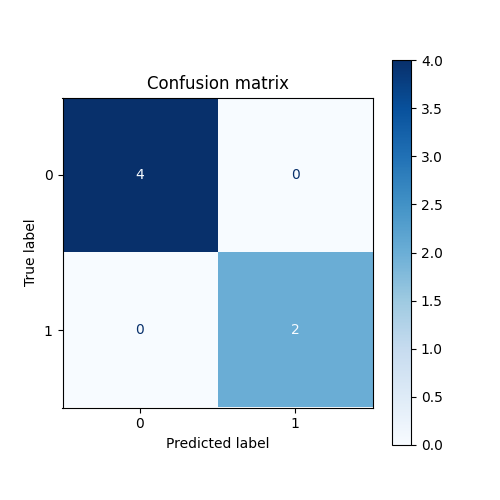

              precision    recall  f1-score   support

     Passive       1.00      1.00      1.00         4
      Active       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from IPython.display import Image, display

# --- Confusion matrix ---
y_true = []
y_pred = []

for batch in test_dataset:
    # batch = (inputs_dict, labels)
    inputs_dict, labels = batch

    # Prédictions
    preds = multi_cam_model.predict(inputs_dict, verbose=0)

    # Binarisation
    preds_binary = (preds > 0.5).astype(int).flatten()

    y_pred.extend(preds_binary)
    y_true.extend(labels.numpy().astype(int).flatten())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion matrix")
plt.grid(False)
plt.savefig("/home/amerzone/kth/Confusion_Matrix.png")
plt.close()
display(Image("/home/amerzone/kth/Confusion_Matrix.png"))

# --- Classification report ---
report = classification_report(y_true, y_pred, target_names=['Passive', 'Active'])
print(report)
